In [83]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import pandas as pd
from cmdstanpy import CmdStanModel

PARTICIPANT = "kr"

df = pd.read_csv("../rr98.csv")
df = df[df["outlier"] == False].copy()
df["correct"] = df["correct"].astype(int)
df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

def _qcut_levels(s, n_levels=7):
    return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
df["cell"] = (df["sat_id"] - 1) * 7 + df["diff_level"]

def build_data(pid):
    d = df[df["id"] == pid]
    d_correct = d[d["correct"] == 1]
    d_false = d[d["correct"] == 0]
    max_rt = float(d["rt"].max())
    t0_hi = float(d["rt"].quantile(0.05))
    return {
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(), "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "max_rt": max_rt, "t0_hi": t0_hi,
    }

def init_ddm(data):
    return {
        "a": [2.10, 2.16], "v_base": [2.8]*7,
        "sv": 0.1, "sz": 0.05,
        "t0": 0.2 * data["t0_hi"], "p_lapse": 0.02,
    }

model = CmdStanModel(stan_file="DDM_rr98_analytic_svfixed.stan")
data = build_data(PARTICIPANT)
inits = init_ddm(data)

mle = model.optimize(
    data=data, inits=inits,
    algorithm="lbfgs",       # default; "bfgs" or "newton" also available if this struggles
    iter=3000,                # optimizer iterations, not MCMC - cheap to set generously
    show_console=True,
)

print(mle.optimized_params_pd)
mle.optimized_params_pd.to_csv(f"map_estimate_{PARTICIPANT}.csv", index=False)

20:50:59 - cmdstanpy - INFO - compiling stan file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/DDM_rr98_analytic_svfixed.stan to exe file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/DDM_rr98_analytic_svfixed
20:51:25 - cmdstanpy - INFO - compiled model executable: /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/DDM_rr98_analytic_svfixed
20:51:25 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = optimize
Chain [1] optimize
Chain [1] algorithm = lbfgs (Default)
Chain [1] lbfgs
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] jacobian = false (Default)
Chain [1] iter = 3000
Chain [1] save_iterations = false (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/7evd8nc1.json
Chain [1] init = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/e5oxcb1c.json
Chain [1] random
Chain [1] seed = 89904
Chain [1] output
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/DDM_rr98_analytic_svfixedmiw4psts/DDM_rr98_analytic_svfixed-20260721205125.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 100 (Default)
Chain [1] sig_f

20:53:18 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 392      -17.6343   1.89553e-05     0.0100041           1           1      429
Chain [1] Optimization terminated normally:
Chain [1] Convergence detected: relative gradient magnitude is below tolerance
Chain [1] 
       lp__      a[1]      a[2]  v_base[1]  v_base[2]  v_base[3]  v_base[4]  \
0 -17.63432  0.707499  1.646255     2.4264   0.922438   0.115963   0.073817   

   v_base[5]  v_base[6]  v_base[7]  ...  log_lik[7572]  log_lik[7573]  \
0   0.477791    1.67386   3.005947  ...      -2.896036      -1.842717   

   log_lik[7574]  log_lik[7575]  log_lik[7576]  log_lik[7577]  log_lik[7578]  \
0      -3.300067      -1.727779      -3.164135      -1.941504      -3.526757   

   log_lik[7579]  log_lik[7580]  log_lik[7581]  
0      -1.998159      -2.148718      -2.787811  

[1 rows x 7623 columns]


In [94]:
df = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/map_estimate_kr.csv")
print(df["sv"])
print(df["sz"])
df[df.columns[:15]]

0    0.018858
Name: sv, dtype: float64
0    0.050848
Name: sz, dtype: float64


,lp__,a[1],a[2],v_base[1],v_base[2],v_base[3],v_base[4],v_base[5],v_base[6],v_base[7],sv,sz,t0,p_lapse,a_full[1]
0,-17.63432,0.707499,1.646255,2.4264,0.922438,0.115963,0.073817,0.477791,1.67386,3.005947,0.018858,0.050848,0.203581,0.07231,0.707499


In [95]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import pandas as pd
from cmdstanpy import CmdStanModel

PARTICIPANT = "kr"

df = pd.read_csv("../rr98.csv")
df = df[df["outlier"] == False].copy()
df["correct"] = df["correct"].astype(int)
df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

def _qcut_levels(s, n_levels=7):
    return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
df["cell"] = (df["sat_id"] - 1) * 7 + df["diff_level"]

def build_data(pid):
    d = df[df["id"] == pid]
    d_correct = d[d["correct"] == 1]
    d_false = d[d["correct"] == 0]
    max_rt = float(d["rt"].max())
    t0_hi = float(d["rt"].quantile(0.05))
    return {
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(), "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "max_rt": max_rt, "t0_hi": t0_hi,
    }

def init_srdm(data):
    return {
        "c": [0.0, 0.0], "B": 1.0,
        "t0": 0.5 * data["t0_hi"],
        "d_base": [1.5]*7, "r": 4.5, "p_lapse": 0.02,
    }

model = CmdStanModel(stan_file="/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/Only1par/SRDM_rr98_c_only.stan")
data = build_data(PARTICIPANT)
inits = init_srdm(data)

mle = model.optimize(
    data=data, inits=inits,
    algorithm="lbfgs",       # default; "bfgs" or "newton" also available if this struggles
    iter=3000,                # optimizer iterations, not MCMC - cheap to set generously
    show_console=True,
)

print(mle.optimized_params_pd)
mle.optimized_params_pd.to_csv(f"map_estimate_srdm_c_only_{PARTICIPANT}.csv", index=False)

02:17:16 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = optimize
Chain [1] optimize
Chain [1] algorithm = lbfgs (Default)
Chain [1] lbfgs
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] jacobian = false (Default)
Chain [1] iter = 3000
Chain [1] save_iterations = false (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/53arq_qf.json
Chain [1] init = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/np_bxbi7.json
Chain [1] random
Chain [1] seed = 83077
Chain [1] output
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/SRDM_rr98_c_only39fd35nd/SRDM_rr98_c_only-20260722021716.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 100 (Default)
Chain [1] sig_figs = 8 (Default)


02:17:20 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 271       1016.13    0.00018027      0.155397           1           1      332
Chain [1] Optimization terminated normally:
Chain [1] Convergence detected: relative gradient magnitude is below tolerance
Chain [1] 
Chain [1] 
        lp__      c[1]      c[2]        B        t0  d_base[1]  d_base[2]  \
0  1016.1333 -0.599835  0.682697  3.24605  0.084597   1.066539   0.419226   

   d_base[3]  d_base[4]  d_base[5]  ...  log_lik[7572]  log_lik[7573]  \
0   0.063936   0.033201   0.212552  ...      -2.788496       -2.39976   

   log_lik[7574]  log_lik[7575]  log_lik[7576]  log_lik[7577]  log_lik[7578]  \
0      -2.764226      -2.212247      -2.861654       -2.17415       -2.84895   

   log_lik[7579]  log_lik[7580]  log_lik[7581]  
0      -2.591638      -1.736814      -2.868625  

[1 rows x 7721 columns]


In [97]:
df_c_only = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/map_estimate_srdm_c_only_kr.csv")
df_c_only[df_c_only.columns[:15]]

,lp__,c[1],c[2],B,t0,d_base[1],d_base[2],d_base[3],d_base[4],d_base[5],d_base[6],d_base[7],r,p_lapse,c_full[1]
0,1016.1333,-0.599835,0.682697,3.24605,0.084597,1.066539,0.419226,0.063936,0.033201,0.212552,0.747342,1.34667,16.642463,0.141026,-0.599835


In [99]:
import pandas as pd
import numpy as np

def aic_bic_from_map(csv_path, n_params):
    df = pd.read_csv(csv_path)
    log_lik_cols = [c for c in df.columns if c.startswith("log_lik")]
    total_log_lik = df[log_lik_cols].iloc[0].sum()
    n_trials = len(log_lik_cols)

    aic = 2 * n_params - 2 * total_log_lik
    bic = n_params * np.log(n_trials) - 2 * total_log_lik

    return {
        "n_params": n_params, "n_trials": n_trials,
        "log_lik": total_log_lik, "AIC": aic, "BIC": bic,
    }

ddm_result  = aic_bic_from_map("map_estimate_nh.csv", n_params=13)          # a[2]+v_base[7]+sv+sz+t0+p_lapse
srdm_result = aic_bic_from_map("map_estimate_srdm_c_only_nh.csv", n_params=13)  # c[2]+B+t0+d_base[7]+r+p_lapse

print("DDM:", ddm_result)
print("SRDM c_only:", srdm_result)
print("\nΔAIC (DDM - SRDM):", ddm_result["AIC"] - srdm_result["AIC"])
print("ΔBIC (DDM - SRDM):", ddm_result["BIC"] - srdm_result["BIC"])

DDM: {'n_params': 13, 'n_trials': 8532, 'log_lik': 1134.3865542181302, 'AIC': -2242.7731084362604, 'BIC': -2151.1025804015744}
SRDM c_only: {'n_params': 13, 'n_trials': 8532, 'log_lik': 2224.32592124218, 'AIC': -4422.65184248436, 'BIC': -4330.981314449674}

ΔAIC (DDM - SRDM): 2179.8787340480994
ΔBIC (DDM - SRDM): 2179.8787340480994


In [48]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import pandas as pd
from cmdstanpy import CmdStanModel

PARTICIPANT = "nh"

df = pd.read_csv("../rr98.csv")
df = df[df["outlier"] == False].copy()
df["correct"] = df["correct"].astype(int)
df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

def _qcut_levels(s, n_levels=7):
    return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
df["cell"] = (df["sat_id"] - 1) * 7 + df["diff_level"]

def build_data(pid):
    d = df[df["id"] == pid]
    d_correct = d[d["correct"] == 1]
    d_false = d[d["correct"] == 0]
    max_rt = float(d["rt"].max())
    # t0_hi is now per-SAT (vector[2]) - the c_t0 model needs one bound per
    # condition, not one pooled bound shared across speed and accuracy
    t0_hi = [
        float(d[d["sat_id"] == 1]["rt"].quantile(0.05)),  # speed
        float(d[d["sat_id"] == 2]["rt"].quantile(0.05)),  # accuracy
    ]
    return {
        "N_correct": len(d_correct), "N_false": len(d_false),
        "rt_correct": d_correct["rt"].to_numpy(), "rt_false": d_false["rt"].to_numpy(),
        "cell_correct": d_correct["cell"].to_numpy(dtype=int),
        "cell_false": d_false["cell"].to_numpy(dtype=int),
        "max_rt": max_rt, "t0_hi": t0_hi,
    }

def init_srdm(data):
    return {
        "c": [0.0, 0.0], "B": 1.0,
        "t0": [0.5 * data["t0_hi"][0], 0.5 * data["t0_hi"][1]],
        "d_base": [1.5]*7, "r": 4.5, "p_lapse": 0.02,
    }

model = CmdStanModel(stan_file="SRDM_rr98_c_t0.stan")
data = build_data(PARTICIPANT)
inits = init_srdm(data)

mle = model.optimize(
    data=data, inits=inits,
    algorithm="lbfgs",       # default; "bfgs" or "newton" also available if this struggles
    iter=3000,                # optimizer iterations, not MCMC - cheap to set generously
    show_console=True,
)

print(mle.optimized_params_pd)
mle.optimized_params_pd.to_csv(f"map_estimate_srdm_c_t0_{PARTICIPANT}.csv", index=False)

17:04:37 - cmdstanpy - INFO - compiling stan file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/SRDM_rr98_c_t0.stan to exe file /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/SRDM_rr98_c_t0
17:05:28 - cmdstanpy - INFO - compiled model executable: /Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/SRDM_rr98_c_t0
17:05:28 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = optimize
Chain [1] optimize
Chain [1] algorithm = lbfgs (Default)
Chain [1] lbfgs
Chain [1] init_alpha = 0.001 (Default)
Chain [1] tol_obj = 1e-12 (Default)
Chain [1] tol_rel_obj = 10000 (Default)
Chain [1] tol_grad = 1e-08 (Default)
Chain [1] tol_rel_grad = 1e+07 (Default)
Chain [1] tol_param = 1e-08 (Default)
Chain [1] history_size = 5 (Default)
Chain [1] jacobian = false (Default)
Chain [1] iter = 3000
Chain [1] save_iterations = false (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/ko6r76dy.json
Chain [1] init = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/ubre6sw7.json
Chain [1] random
Chain [1] seed = 63985
Chain [1] output
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp_iaa4why/SRDM_rr98_c_t026iile6d/SRDM_rr98_c_t0-20260721170528.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 100 (Default)
Chain [1] sig_figs = 8 (Default)
Chai

17:05:31 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 199       2211.65    0.00144268       2.22789           1           1      244
Chain [1] Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes
Chain [1] 216       2211.65   0.000296329      0.217697           1           1      264
Chain [1] Optimization terminated normally:
Chain [1] Convergence detected: relative gradient magnitude is below tolerance
Chain [1] 
Chain [1] 
        lp__      c[1]    c[2]         B     t0[1]     t0[2]  d_base[1]  \
0  2211.6473 -0.516813  0.2577  2.666532  0.099785  0.126749   1.320862   

   d_base[2]  d_base[3]  d_base[4]  ...  log_lik[8523]  log_lik[8524]  \
0   0.604346    0.13835   0.077728  ...      -0.782346       0.607297   

   log_lik[8525]  log_lik[8526]  log_lik[8527]  log_lik[8528]  log_lik[8529]  \
0       0.049536      -0.199841        0.41085       0.238974       0.351536   

   log_lik[8530]  log_lik[8531]  log_lik[8532]  
0      -0.179102       0.907872       0.349791  

[1 rows x 8673 columns

In [ ]:
df_t0_c = pd.read_csv("/Users/Anton/Documents/ForskningsprojektSommer2026/RR98fit/DDM/map_estimate_srdm_c_t0_nh.csv")
df_t0_c[""]

0    0.070367
Name: p_lapse, dtype: float64

In [75]:
import pandas as pd
import numpy as np

def aic_bic_from_map(csv_path, n_params):
    df = pd.read_csv(csv_path)
    log_lik_cols = [c for c in df.columns if c.startswith("log_lik")]
    total_log_lik = df[log_lik_cols].iloc[0].sum()
    n_trials = len(log_lik_cols)

    aic = 2 * n_params - 2 * total_log_lik
    bic = n_params * np.log(n_trials) - 2 * total_log_lik

    return {
        "n_params": n_params, "n_trials": n_trials,
        "log_lik": total_log_lik, "AIC": aic, "BIC": bic,
    }

ddm_result  = aic_bic_from_map("map_estimate_jf.csv", n_params=13)          # a[2]+v_base[7]+sv+sz+t0+p_lapse
srdm_result = aic_bic_from_map("map_estimate_srdm_c_only_jf.csv", n_params=13)  # c[2]+B+t0+d_base[7]+r+p_lapse


print("DDM:", ddm_result)
print("SRDM c_only:", srdm_result)

print("\nΔAIC (DDM - SRDM):", ddm_result["AIC"] - srdm_result["AIC"])
print("ΔBIC (DDM - SRDM):", ddm_result["BIC"] - srdm_result["BIC"])

DDM: {'n_params': 13, 'n_trials': 7735, 'log_lik': -196.6151433433298, 'AIC': 419.2302866866596, 'BIC': 509.62592660575274}
SRDM c_only: {'n_params': 13, 'n_trials': 7735, 'log_lik': 1318.2846578664798, 'AIC': -2610.5693157329597, 'BIC': -2520.1736758138663}

ΔAIC (DDM - SRDM): 3029.799602419619
ΔBIC (DDM - SRDM): 3029.799602419619


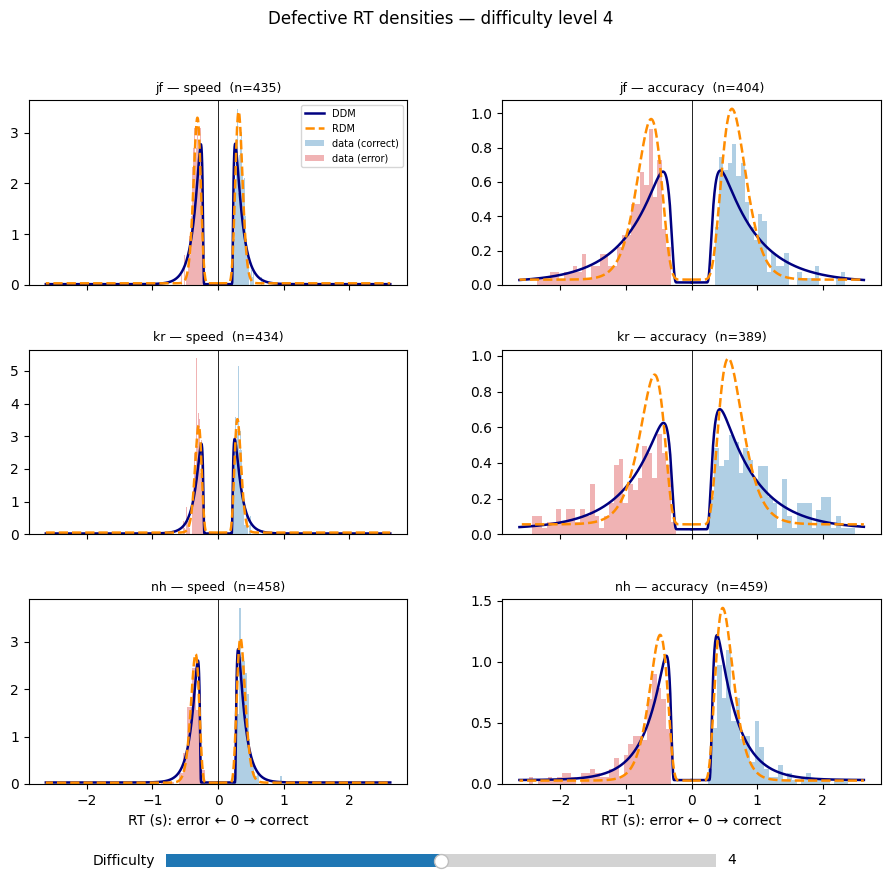

In [72]:
#!/usr/bin/env python3
"""
RT distributions vs. defective densities: DDM vs RDM (rr98)
=============================================================
Loads your ALREADY-COMPUTED MAP fit CSVs (from optimize()) - no refitting,
no CmdStan needed for this script at all. Just points at the .csv files you
already have and plots.

Opens an interactive figure:
  - 3x2 grid: rows = participants (jf, kr, nh), columns = speed / accuracy
  - each panel: correct RTs (positive x-axis) and error RTs (mirrored,
    negative x-axis) shown as histograms scaled by their own empirical
    response proportion, overlaid with the DDM's and RDM's predicted
    defective density curves
  - a slider at the bottom controls the difficulty level (1-7), updating
    all six panels at once

Requirements: pandas, numpy, scipy, matplotlib  (no cmdstanpy needed here)

Edit FIT_PATHS below to point at whichever map_estimate_*.csv files you
have. Missing a participant/model? Just leave it out of the dict - that
panel will show the data only, with a note that the fit is missing.
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ── configuration - EDIT THESE ─────────────────────────────────────────────
DATA_PATH = "../rr98.csv"

# point these at whichever MAP csvs you actually have; leave a participant
# out of either dict if you don't have that fit yet
DDM_FIT_PATHS = {
    "jf": "map_estimate_jf.csv",
    "kr": "map_estimate_kr.csv",
    "nh": "map_estimate_nh.csv",
}
SRDM_FIT_PATHS = {
    "jf": "map_estimate_srdm_c_only_jf.csv",
    "kr": "map_estimate_srdm_c_only_kr.csv",
    "nh": "map_estimate_srdm_c_only_nh.csv",
}

PARTICIPANTS = ["jf", "kr", "nh"]
CONDITIONS   = ["speed", "accuracy"]
N_DIFFICULTY = 7


# ═══════════════════════════════════════════════════════════════════════
# Data prep (matches the rest of the project's convention)
# ═══════════════════════════════════════════════════════════════════════
def load_data():
    df = pd.read_csv(DATA_PATH)
    df = df[df["outlier"] == False].copy()
    df["correct"] = df["correct"].astype(int)
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

    def _qcut_levels(s, n_levels=7):
        return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

    df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
    df["cell"] = (df["sat_id"] - 1) * 7 + df["diff_level"]
    return df


# ═══════════════════════════════════════════════════════════════════════
# Load fitted parameters straight from the optimize() output CSVs
# ═══════════════════════════════════════════════════════════════════════
def load_ddm_fit(csv_path, max_rt):
    row = pd.read_csv(csv_path).iloc[0]
    return {
        "a": [row["a[1]"], row["a[2]"]],
        "v_base": [row[f"v_base[{i}]"] for i in range(1, 8)],
        "sv": row["sv"], "sz": row["sz"], "t0": row["t0"], "p_lapse": row["p_lapse"],
        "max_rt": max_rt,
    }


def load_srdm_fit(csv_path, max_rt):
    row = pd.read_csv(csv_path).iloc[0]
    return {
        "c": [row["c[1]"], row["c[2]"]],
        "d_base": [row[f"d_base[{i}]"] for i in range(1, 8)],
        "B": row["B"], "r": row["r"], "t0": row["t0"], "p_lapse": row["p_lapse"],
        "max_rt": max_rt,
    }


# ═══════════════════════════════════════════════════════════════════════
# DDM density: Blurton, Kesselmeier & Gondan (2017) analytic-sv formula.
# Branch assignment (correct: nu=+v, w=1-w_node; false: nu=-v, w=w_node)
# was verified against the closed-form two-boundary hitting probability.
# sz integrated via 5-pt Gauss-Legendre quadrature, matching the Stan model.
# ═══════════════════════════════════════════════════════════════════════
_GL_NODES = np.array([-0.90617985, -0.53846931, 0.0, 0.53846931, 0.90617985])
_GL_WEIGHT = np.array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689]) / 2.0


def _bkg_density(t, nu, eta, a, w, J=15):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    valid = t > 0
    tt = t[valid]
    log_prefactor = (-0.5*np.log(tt**3*(1+eta**2*tt))
                     - (nu**2*tt - 2*nu*a*w + eta**2*(a*w)**2) / (2*(1+eta**2*tt)))
    total = np.zeros_like(tt)
    sign = 1.0
    for j in range(J+1):
        r_j = j*a + a*w if j % 2 == 0 else j*a + a*(1 - w)
        phi_val = np.exp(-0.5*(r_j/np.sqrt(tt))**2) / np.sqrt(2*np.pi)
        total += sign * r_j * phi_val
        sign = -sign
    out[valid] = np.exp(log_prefactor) * np.maximum(total, 0)
    return out


def ddm_wiener_density(t_dec, v, a, sv, sz, response):
    total = np.zeros_like(t_dec, dtype=float)
    for node, wgt in zip(_GL_NODES, _GL_WEIGHT):
        w_node = 0.5 + (sz/2)*node
        if response == "correct":
            total += wgt * _bkg_density(t_dec, v, sv, a, 1 - w_node)
        else:
            total += wgt * _bkg_density(t_dec, -v, sv, a, w_node)
    return total


def ddm_defective_pdf(rt, v, a, t0, sv, sz, p_lapse, max_rt, response,
                       t0_blend_width=0.03):
    rt = np.asarray(rt, dtype=float)
    t_raw = rt - t0
    t_dec = np.maximum(t_raw, 1e-4)
    blend_w = 1 / (1 + np.exp(-t_raw/t0_blend_width))
    wiener_dens = ddm_wiener_density(t_dec, v, a, sv, sz, response)
    lapse_dens = 1.0 / max_rt
    return blend_w * (1 - p_lapse) * wiener_dens + p_lapse * lapse_dens


# ═══════════════════════════════════════════════════════════════════════
# RDM/SRDM density: Wald race (winning accumulator's density x losing
# accumulator's survival). Verified to integrate exactly to 1 (correct +
# error) with no lapse/t0 contamination.
# ═══════════════════════════════════════════════════════════════════════
def _wald_pdf(t, v, s, B):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    tt = t[ok]
    out[ok] = (B/np.sqrt(2*np.pi*s**2*tt**3)) * np.exp(-(v*tt-B)**2/(2*s**2*tt))
    return out


def _wald_cdf(t, v, s, B):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    tt = t[ok]
    sq = np.sqrt(tt)
    a1 = (v*tt - B)/(s*sq)
    a2 = (v*tt + B)/(s*sq)
    ev = np.minimum(2*B*v/s**2, 700)
    out[ok] = norm.cdf(a1) + np.exp(ev)*norm.cdf(-a2)
    return np.clip(out, 0, 1)


def srdm_wiener_density(t_dec, own_v, own_sig, oth_v, oth_sig, B):
    f_own = _wald_pdf(t_dec, own_v, own_sig, B)
    F_oth = _wald_cdf(t_dec, oth_v, oth_sig, B)
    return f_own * (1 - F_oth)


def srdm_defective_pdf(rt, c, d_level, B, t0, r, p_lapse, max_rt, response,
                        t0_blend_width=0.03):
    rt = np.asarray(rt, dtype=float)
    t_raw = rt - t0
    t_dec = np.maximum(t_raw, 1e-4)
    blend_w = 1 / (1 + np.exp(-t_raw/t0_blend_width))

    pk = np.clip(norm.cdf(d_level/2 - c), 1e-6, 1-1e-6)
    pf = np.clip(norm.cdf(-d_level/2 - c), 1e-6, 1-1e-6)
    vk, vf = pk*r, pf*r
    sk = max(np.sqrt(pk*(1-pk)*r), 0.05)
    sf = max(np.sqrt(pf*(1-pf)*r), 0.05)

    if response == "correct":
        wiener_dens = srdm_wiener_density(t_dec, vk, sk, vf, sf, B)
    else:
        wiener_dens = srdm_wiener_density(t_dec, vf, sf, vk, sk, B)

    lapse_dens = 1.0 / max_rt
    return blend_w * (1 - p_lapse) * wiener_dens + p_lapse * lapse_dens


# ═══════════════════════════════════════════════════════════════════════
# Main: load fits (if present), then build the interactive figure
# ═══════════════════════════════════════════════════════════════════════
def main():
    df = load_data()

    ddm_fits, srdm_fits = {}, {}
    for pid in PARTICIPANTS:
        max_rt = float(df.loc[df["id"] == pid, "rt"].max())
        if pid in DDM_FIT_PATHS:
            try:
                ddm_fits[pid] = load_ddm_fit(DDM_FIT_PATHS[pid], max_rt)
            except FileNotFoundError:
                print(f"[warning] DDM fit not found for {pid}: {DDM_FIT_PATHS[pid]}")
        if pid in SRDM_FIT_PATHS:
            try:
                srdm_fits[pid] = load_srdm_fit(SRDM_FIT_PATHS[pid], max_rt)
            except FileNotFoundError:
                print(f"[warning] SRDM fit not found for {pid}: {SRDM_FIT_PATHS[pid]}")

    fig, axes = plt.subplots(len(PARTICIPANTS), len(CONDITIONS),
                              figsize=(11, 9), sharex=True)
    plt.subplots_adjust(bottom=0.12, hspace=0.35, wspace=0.25)

    rt_grid = np.linspace(1e-4, df["rt"].max()*1.05, 500)

    def draw(difficulty):
        for i, pid in enumerate(PARTICIPANTS):
            for j, cond in enumerate(CONDITIONS):
                ax = axes[i, j]
                ax.clear()
                sat_id = 1 if cond == "speed" else 2
                cell = (sat_id - 1)*7 + difficulty

                sub = df[(df["id"] == pid) & (df["cell"] == cell)]
                n_total = len(sub)
                rt_correct = sub.loc[sub["correct"] == 1, "rt"].to_numpy()
                rt_error = sub.loc[sub["correct"] == 0, "rt"].to_numpy()

                p_correct_emp = len(rt_correct)/n_total if n_total else 0
                p_error_emp = len(rt_error)/n_total if n_total else 0

                if len(rt_correct) > 0:
                    counts, bins_ = np.histogram(rt_correct, bins=30, density=True)
                    counts = counts * p_correct_emp
                    ax.bar(bins_[:-1], counts, width=np.diff(bins_), align="edge",
                           color="tab:blue", alpha=0.35, label="data (correct)")
                if len(rt_error) > 0:
                    counts, bins_ = np.histogram(rt_error, bins=30, density=True)
                    counts = counts * p_error_emp
                    ax.bar(-bins_[1:], counts, width=np.diff(bins_), align="edge",
                           color="tab:red", alpha=0.35, label="data (error)")

                if pid in ddm_fits:
                    fd = ddm_fits[pid]
                    a_sat = fd["a"][sat_id - 1]
                    v = fd["v_base"][difficulty - 1]
                    ddm_c = ddm_defective_pdf(rt_grid, v, a_sat, fd["t0"], fd["sv"], fd["sz"],
                                              fd["p_lapse"], fd["max_rt"], "correct")
                    ddm_e = ddm_defective_pdf(rt_grid, v, a_sat, fd["t0"], fd["sv"], fd["sz"],
                                              fd["p_lapse"], fd["max_rt"], "error")
                    ax.plot(rt_grid, ddm_c, color="navy", lw=1.8, label="DDM")
                    ax.plot(-rt_grid, ddm_e, color="navy", lw=1.8)

                if pid in srdm_fits:
                    fs = srdm_fits[pid]
                    c_sat = fs["c"][sat_id - 1]
                    d_level = fs["d_base"][difficulty - 1]
                    rdm_c = srdm_defective_pdf(rt_grid, c_sat, d_level, fs["B"], fs["t0"],
                                               fs["r"], fs["p_lapse"], fs["max_rt"], "correct")
                    rdm_e = srdm_defective_pdf(rt_grid, c_sat, d_level, fs["B"], fs["t0"],
                                               fs["r"], fs["p_lapse"], fs["max_rt"], "error")
                    ax.plot(rt_grid, rdm_c, color="darkorange", lw=1.8, ls="--", label="RDM")
                    ax.plot(-rt_grid, rdm_e, color="darkorange", lw=1.8, ls="--")

                ax.axvline(0, color="black", lw=0.6)
                ax.set_title(f"{pid} — {cond}  (n={n_total})", fontsize=9)
                if i == 0 and j == 0:
                    ax.legend(fontsize=7, loc="upper right")
                if i == len(PARTICIPANTS)-1:
                    ax.set_xlabel("RT (s): error ← 0 → correct")

        fig.suptitle(f"Defective RT densities — difficulty level {difficulty}", fontsize=12)
        fig.canvas.draw_idle()

    draw(4)

    ax_slider = plt.axes([0.25, 0.02, 0.5, 0.03])
    slider = Slider(ax_slider, "Difficulty", 1, N_DIFFICULTY, valinit=4, valstep=1)
    slider.on_changed(lambda val: draw(int(val)))

    plt.show()


if __name__ == "__main__":
    main()

In [89]:
#!/usr/bin/env python3
"""
RT distributions vs. defective densities: DDM vs RDM (rr98)
=============================================================
Loads your ALREADY-COMPUTED MAP fit CSVs (from optimize()) - no refitting,
no CmdStan needed for this script at all. Just points at the .csv files you
already have and plots.

Opens an interactive figure:
  - 3x2 grid: rows = participants (jf, kr, nh), columns = speed / accuracy
  - each panel: correct RTs (positive x-axis) and error RTs (mirrored,
    negative x-axis) shown as histograms scaled by their own empirical
    response proportion, overlaid with the DDM's and RDM's predicted
    defective density curves
  - a slider at the bottom controls the difficulty level (1-7), updating
    all six panels at once

Requirements: pandas, numpy, scipy, matplotlib  (no cmdstanpy needed here)

Edit FIT_PATHS below to point at whichever map_estimate_*.csv files you
have. Missing a participant/model? Just leave it out of the dict - that
panel will show the data only, with a note that the fit is missing.
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
# For Jupyter: run  %matplotlib inline  in a cell before importing this.
# The difficulty slider uses ipywidgets.interact, which is Jupyter-native.
try:
    from ipywidgets import interact, IntSlider
    _HAS_IPYWIDGETS = True
except ImportError:
    from matplotlib.widgets import Slider
    _HAS_IPYWIDGETS = False

# ── configuration - EDIT THESE ─────────────────────────────────────────────
DATA_PATH = "../rr98.csv"

# point these at whichever MAP csvs you actually have; leave a participant
# out of either dict if you don't have that fit yet
DDM_FIT_PATHS = {
    "jf": "map_estimate_jf.csv",
    "kr": "map_estimate_kr.csv",
    "nh": "map_estimate_nh.csv",
}
SRDM_FIT_PATHS = {
    "jf": "map_estimate_srdm_c_only_jf.csv",
    "kr": "map_estimate_srdm_c_only_kr.csv",
    "nh": "map_estimate_srdm_c_only_nh.csv",
}

PARTICIPANTS = ["jf", "kr", "nh"]
CONDITIONS   = ["speed", "accuracy"]
N_DIFFICULTY = 7


# ═══════════════════════════════════════════════════════════════════════
# Data prep (matches the rest of the project's convention)
# ═══════════════════════════════════════════════════════════════════════
def load_data():
    df = pd.read_csv(DATA_PATH)
    df = df[df["outlier"] == False].copy()
    df["correct"] = df["correct"].astype(int)
    df["sat_id"] = df["instruction"].map({"speed": 1, "accuracy": 2})

    def _qcut_levels(s, n_levels=7):
        return pd.qcut(s, q=n_levels, labels=False, duplicates="drop") + 1

    df["diff_level"] = df.groupby("id")["strength"].transform(_qcut_levels)
    df["cell"] = (df["sat_id"] - 1) * 7 + df["diff_level"]
    return df


# ═══════════════════════════════════════════════════════════════════════
# Load fitted parameters straight from the optimize() output CSVs
# ═══════════════════════════════════════════════════════════════════════
def load_ddm_fit(csv_path, max_rt):
    row = pd.read_csv(csv_path).iloc[0]
    return {
        "a": [row["a[1]"], row["a[2]"]],
        "v_base": [row[f"v_base[{i}]"] for i in range(1, 8)],
        "sv": row["sv"], "sz": row["sz"], "t0": row["t0"], "p_lapse": row["p_lapse"],
        "max_rt": max_rt,
    }


def load_srdm_fit(csv_path, max_rt):
    row = pd.read_csv(csv_path).iloc[0]
    return {
        "c": [row["c[1]"], row["c[2]"]],
        "d_base": [row[f"d_base[{i}]"] for i in range(1, 8)],
        "B": row["B"], "r": row["r"], "t0": row["t0"], "p_lapse": row["p_lapse"],
        "max_rt": max_rt,
    }


# ═══════════════════════════════════════════════════════════════════════
# DDM density: Blurton, Kesselmeier & Gondan (2017) analytic-sv formula.
# Branch assignment (correct: nu=+v, w=1-w_node; false: nu=-v, w=w_node)
# was verified against the closed-form two-boundary hitting probability.
# sz integrated via 5-pt Gauss-Legendre quadrature, matching the Stan model.
# ═══════════════════════════════════════════════════════════════════════
_GL_NODES = np.array([-0.90617985, -0.53846931, 0.0, 0.53846931, 0.90617985])
_GL_WEIGHT = np.array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689]) / 2.0


def _bkg_density(t, nu, eta, a, w, J=15):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    valid = t > 0
    tt = t[valid]
    log_prefactor = (-0.5*np.log(tt**3*(1+eta**2*tt))
                     - (nu**2*tt - 2*nu*a*w + eta**2*(a*w)**2) / (2*(1+eta**2*tt)))
    total = np.zeros_like(tt)
    sign = 1.0
    for j in range(J+1):
        r_j = j*a + a*w if j % 2 == 0 else j*a + a*(1 - w)
        phi_val = np.exp(-0.5*(r_j/np.sqrt(tt))**2) / np.sqrt(2*np.pi)
        total += sign * r_j * phi_val
        sign = -sign
    out[valid] = np.exp(log_prefactor) * np.maximum(total, 0)
    return out


def ddm_wiener_density(t_dec, v, a, sv, sz, response):
    total = np.zeros_like(t_dec, dtype=float)
    for node, wgt in zip(_GL_NODES, _GL_WEIGHT):
        w_node = 0.5 + (sz/2)*node
        if response == "correct":
            total += wgt * _bkg_density(t_dec, v, sv, a, 1 - w_node)
        else:
            total += wgt * _bkg_density(t_dec, -v, sv, a, w_node)
    return total


def ddm_defective_pdf(rt, v, a, t0, sv, sz, p_lapse, max_rt, response,
                       t0_blend_width=0.03):
    rt = np.asarray(rt, dtype=float)
    t_raw = rt - t0
    t_dec = np.maximum(t_raw, 1e-4)
    blend_w = 1 / (1 + np.exp(-t_raw/t0_blend_width))
    wiener_dens = ddm_wiener_density(t_dec, v, a, sv, sz, response)
    lapse_dens = 1.0 / max_rt
    return blend_w * (1 - p_lapse) * wiener_dens + p_lapse * lapse_dens


# ═══════════════════════════════════════════════════════════════════════
# RDM/SRDM density: Wald race (winning accumulator's density x losing
# accumulator's survival). Verified to integrate exactly to 1 (correct +
# error) with no lapse/t0 contamination.
# ═══════════════════════════════════════════════════════════════════════
def _wald_pdf(t, v, s, B):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    tt = t[ok]
    out[ok] = (B/np.sqrt(2*np.pi*s**2*tt**3)) * np.exp(-(v*tt-B)**2/(2*s**2*tt))
    return out


def _wald_cdf(t, v, s, B):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    tt = t[ok]
    sq = np.sqrt(tt)
    a1 = (v*tt - B)/(s*sq)
    a2 = (v*tt + B)/(s*sq)
    ev = np.minimum(2*B*v/s**2, 700)
    out[ok] = norm.cdf(a1) + np.exp(ev)*norm.cdf(-a2)
    return np.clip(out, 0, 1)


def srdm_wiener_density(t_dec, own_v, own_sig, oth_v, oth_sig, B):
    f_own = _wald_pdf(t_dec, own_v, own_sig, B)
    F_oth = _wald_cdf(t_dec, oth_v, oth_sig, B)
    return f_own * (1 - F_oth)


def srdm_defective_pdf(rt, c, d_level, B, t0, r, p_lapse, max_rt, response,
                        t0_blend_width=0.03):
    rt = np.asarray(rt, dtype=float)
    t_raw = rt - t0
    t_dec = np.maximum(t_raw, 1e-4)
    blend_w = 1 / (1 + np.exp(-t_raw/t0_blend_width))

    pk = np.clip(norm.cdf(d_level/2 - c), 1e-6, 1-1e-6)
    pf = np.clip(norm.cdf(-d_level/2 - c), 1e-6, 1-1e-6)
    vk, vf = pk*r, pf*r
    sk = max(np.sqrt(pk*(1-pk)*r), 0.05)
    sf = max(np.sqrt(pf*(1-pf)*r), 0.05)

    if response == "correct":
        wiener_dens = srdm_wiener_density(t_dec, vk, sk, vf, sf, B)
    else:
        wiener_dens = srdm_wiener_density(t_dec, vf, sf, vk, sk, B)

    lapse_dens = 1.0 / max_rt
    return blend_w * (1 - p_lapse) * wiener_dens + p_lapse * lapse_dens


# ═══════════════════════════════════════════════════════════════════════
# Main: load fits (if present), then build the interactive figure
# ═══════════════════════════════════════════════════════════════════════
def main():
    df = load_data()

    ddm_fits, srdm_fits = {}, {}
    for pid in PARTICIPANTS:
        max_rt = float(df.loc[df["id"] == pid, "rt"].max())
        if pid in DDM_FIT_PATHS:
            try:
                ddm_fits[pid] = load_ddm_fit(DDM_FIT_PATHS[pid], max_rt)
            except FileNotFoundError:
                print(f"[warning] DDM fit not found for {pid}: {DDM_FIT_PATHS[pid]}")
        if pid in SRDM_FIT_PATHS:
            try:
                srdm_fits[pid] = load_srdm_fit(SRDM_FIT_PATHS[pid], max_rt)
            except FileNotFoundError:
                print(f"[warning] SRDM fit not found for {pid}: {SRDM_FIT_PATHS[pid]}")

    rt_grid = np.linspace(1e-4, df["rt"].max()*1.05, 500)

    def draw(difficulty):
        fig, axes = plt.subplots(len(PARTICIPANTS), len(CONDITIONS),
                                  figsize=(11, 9))
        plt.subplots_adjust(hspace=0.35, wspace=0.25)

        for i, pid in enumerate(PARTICIPANTS):
            for j, cond in enumerate(CONDITIONS):
                ax = axes[i, j]
                sat_id = 1 if cond == "speed" else 2
                cell = (sat_id - 1)*7 + difficulty

                sub = df[(df["id"] == pid) & (df["cell"] == cell)]
                n_total = len(sub)
                rt_correct = sub.loc[sub["correct"] == 1, "rt"].to_numpy()
                rt_error = sub.loc[sub["correct"] == 0, "rt"].to_numpy()

                p_correct_emp = len(rt_correct)/n_total if n_total else 0
                p_error_emp = len(rt_error)/n_total if n_total else 0

                if len(rt_correct) > 0:
                    counts, bins_ = np.histogram(rt_correct, bins=30, density=True)
                    counts = counts * p_correct_emp
                    ax.bar(bins_[:-1], counts, width=np.diff(bins_), align="edge",
                           color="tab:blue", alpha=0.35, label="data (correct)")
                if len(rt_error) > 0:
                    counts, bins_ = np.histogram(rt_error, bins=30, density=True)
                    counts = counts * p_error_emp
                    ax.bar(-bins_[1:], counts, width=np.diff(bins_), align="edge",
                           color="tab:red", alpha=0.35, label="data (error)")

                if pid in ddm_fits:
                    fd = ddm_fits[pid]
                    a_sat = fd["a"][sat_id - 1]
                    v = fd["v_base"][difficulty - 1]
                    ddm_c = ddm_defective_pdf(rt_grid, v, a_sat, fd["t0"], fd["sv"], fd["sz"],
                                              fd["p_lapse"], fd["max_rt"], "correct")
                    ddm_e = ddm_defective_pdf(rt_grid, v, a_sat, fd["t0"], fd["sv"], fd["sz"],
                                              fd["p_lapse"], fd["max_rt"], "error")
                    ax.plot(rt_grid, ddm_c, color="navy", lw=1.8, label="DDM")
                    ax.plot(-rt_grid, ddm_e, color="navy", lw=1.8)

                if pid in srdm_fits:
                    fs = srdm_fits[pid]
                    c_sat = fs["c"][sat_id - 1]
                    d_level = fs["d_base"][difficulty - 1]
                    rdm_c = srdm_defective_pdf(rt_grid, c_sat, d_level, fs["B"], fs["t0"],
                                               fs["r"], fs["p_lapse"], fs["max_rt"], "correct")
                    rdm_e = srdm_defective_pdf(rt_grid, c_sat, d_level, fs["B"], fs["t0"],
                                               fs["r"], fs["p_lapse"], fs["max_rt"], "error")
                    ax.plot(rt_grid, rdm_c, color="darkorange", lw=1.8, ls="--", label="RDM")
                    ax.plot(-rt_grid, rdm_e, color="darkorange", lw=1.8, ls="--")

                ax.axvline(0, color="black", lw=0.6)
                ax.set_title(f"{pid} — {cond}  (n={n_total})", fontsize=9)

                # zoom x-axis to where the data actually lives
                all_rt = sub["rt"].to_numpy()
                if len(all_rt) > 0:
                    rt_hi = np.percentile(all_rt, 99) * 1.15
                else:
                    rt_hi = 1.5
                ax.set_xlim(-rt_hi, rt_hi)

                if i == 0 and j == 0:
                    ax.legend(fontsize=7, loc="upper right")
                if i == len(PARTICIPANTS)-1:
                    ax.set_xlabel("RT (s): error ← 0 → correct")

        fig.suptitle(f"Defective RT densities — difficulty level {difficulty}", fontsize=12)
        plt.tight_layout()
        plt.show()

    if _HAS_IPYWIDGETS:
        # Jupyter: ipywidgets slider, redraws the whole figure on change
        interact(draw, difficulty=IntSlider(min=1, max=N_DIFFICULTY, step=1, value=4,
                                            description="Difficulty"))
    else:
        # standalone script: matplotlib Slider fallback
        draw(4)


if __name__ == "__main__":
    main()

interactive(children=(IntSlider(value=4, description='Difficulty', max=7, min=1), Output()), _dom_classes=('wi…